# Análisis — Regresión lineal múltiple desde cero

In [1]:
import os
import sys

raiz = os.path.abspath(os.path.join(os.getcwd(), '..'))
if raiz not in sys.path:
    sys.path.insert(0, raiz)

import math
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.data import (DATA_PATH, FEATURES, FIGURES, load_data,
                      original_scale_params, split_data, standardize)
from src.linear_regression import LinearRegression
from src.metrics import evaluate, r2_score

os.makedirs(FIGURES, exist_ok=True)
epocas = 10000
unidades = {'AT': '°C', 'V': 'cm Hg', 'AP': 'mbar', 'RH': '%'}

def guardar(nombre):
    plt.savefig(f'{FIGURES}/{nombre}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 1. Carga y exploración

In [2]:
datos = pd.read_csv(DATA_PATH)
print('Filas y columnas:', datos.shape)
print('Nulos:', int(datos.isna().sum().sum()))
print('Duplicados:', int(datos.duplicated().sum()))
datos.describe().round(2)

Filas y columnas: (9568, 5)
Nulos: 0
Duplicados: 41


,AT,V,AP,RH,PE
count,9568.00,9568.00,9568.00,9568.00,9568.00
mean,19.65,54.31,1013.26,73.31,454.37
std,7.45,12.71,5.94,14.60,17.07
min,1.81,25.36,992.89,25.56,420.26
25%,13.51,41.74,1009.10,63.33,439.75
50%,20.34,52.08,1012.94,74.97,451.55
75%,25.72,66.54,1017.26,84.83,468.43
max,37.11,81.56,1033.30,100.16,495.76


In [3]:
x, y = load_data(DATA_PATH)
print('Observaciones:', len(y))

pd.DataFrame({'variable': FEATURES,
              'correlacion con PE': [round(np.corrcoef(v, y)[0, 1], 4) for v in x]})

Observaciones: 9527


,variable,correlacion con PE
0,AT,-0.9479
1,V,-0.8699
2,AP,0.5187
3,RH,0.3912


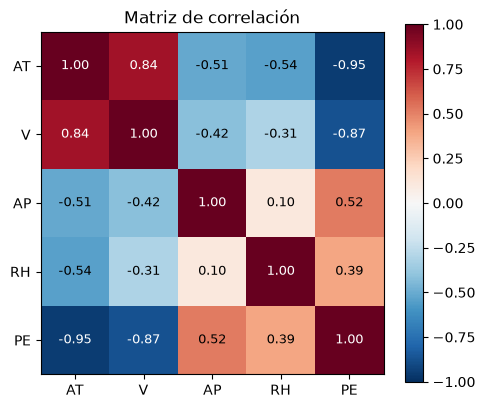

In [4]:
columnas = FEATURES + ['PE']
correlaciones = np.corrcoef(np.array(x + [list(y)]))

fig, ax = plt.subplots(figsize=(5, 4.2))
imagen = ax.imshow(correlaciones, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(columnas)), columnas)
ax.set_yticks(range(len(columnas)), columnas)
for i in range(len(columnas)):
    for j in range(len(columnas)):
        ax.text(j, i, f'{correlaciones[i, j]:.2f}', ha='center', va='center',
                color='white' if abs(correlaciones[i, j]) > .6 else 'black', fontsize=9)
plt.colorbar(imagen)
ax.set_title('Matriz de correlación')
plt.tight_layout()
guardar('correlacion')

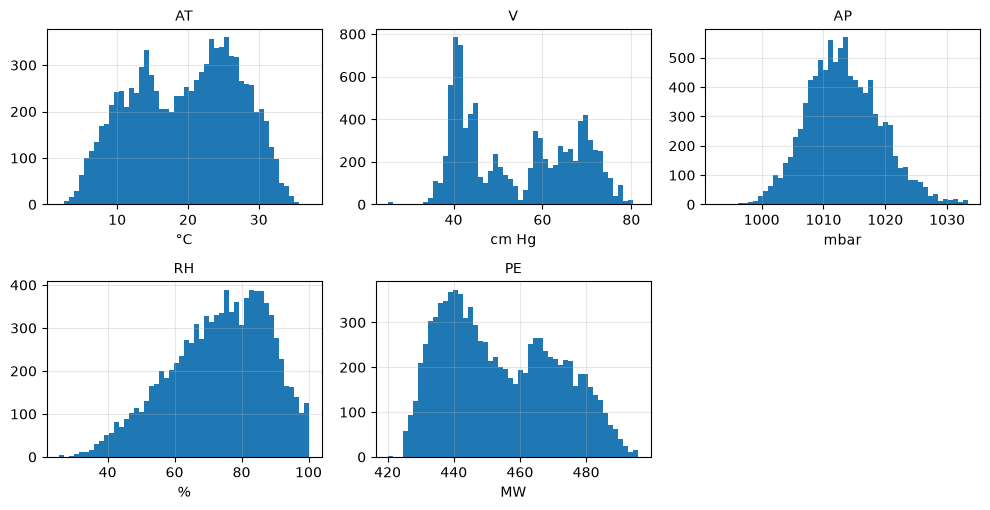

In [5]:
fig, ejes = plt.subplots(2, 3, figsize=(10, 5.2))
for ax, (nombre, valores) in zip(ejes.ravel(), list(zip(FEATURES, x)) + [('PE', list(y))]):
    ax.hist(valores, bins=50)
    ax.set_title(nombre, fontsize=10)
    ax.set_xlabel(unidades.get(nombre, 'MW'))
    ax.grid(alpha=.3)
ejes.ravel()[-1].axis('off')
plt.tight_layout()
guardar('histogramas')

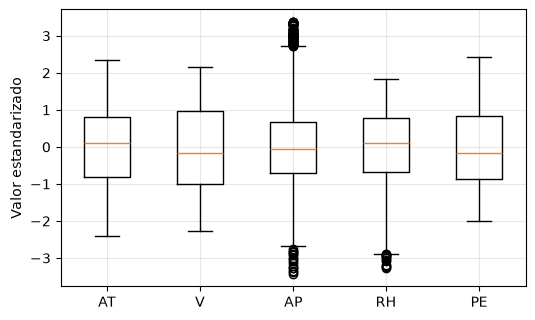

In [6]:
escaladas, _ = standardize(x + [list(y)])
plt.figure(figsize=(6, 3.6))
plt.boxplot(escaladas, tick_labels=columnas)
plt.ylabel('Valor estandarizado')
plt.grid(alpha=.3)
guardar('boxplots')

## 2. Partición y estandarización

In [7]:
random.seed(42)
x_train, y_train, x_val, y_val, x_test, y_test = split_data(x, y)
print('Entrenamiento:', len(y_train))
print('Validación:', len(y_val))
print('Prueba:', len(y_test))

x_train, estadisticos = standardize(x_train)
x_val, _ = standardize(x_val, estadisticos)
x_test, _ = standardize(x_test, estadisticos)

pd.DataFrame({'variable': FEATURES,
              'media': [round(m, 4) for m, _ in estadisticos],
              'desviacion': [round(d, 4) for _, d in estadisticos]})

Entrenamiento: 5716
Validación: 1905
Prueba: 1906


,variable,media,desviacion
0,AT,19.7543,7.4264
1,V,54.4019,12.6856
2,AP,1013.1880,5.8631
3,RH,73.2170,14.8105


## 3. Sin escalar

In [8]:
random.seed(42)
x_crudo, y_crudo, x_crudo_val, y_crudo_val, _, _ = split_data(*load_data(DATA_PATH))

medias_cuadradas = [sum(v ** 2 for v in variable) / len(variable) for variable in x_crudo]
suma = sum(medias_cuadradas) + 1

pesos = pd.DataFrame({'variable': FEATURES,
                      'media cuadrada': [round(m) for m in medias_cuadradas],
                      'porcentaje': [round(100 * m / suma, 2) for m in medias_cuadradas]})
pesos

,variable,media cuadrada,porcentaje
0,AT,445,0.04
1,V,3120,0.30
2,AP,1026584,99.12
3,RH,5580,0.54


In [9]:
random.seed(42)
sin_escalar = LinearRegression([x_crudo, y_crudo], epochs=2000)
sin_escalar.fit()

print('Tasa:', f'{sin_escalar.learning_rate:.3e}')
print('MSE tras 2000 épocas:', round(sin_escalar.loss_history[-1], 2))
print('R2 de validación:', round(r2_score(y_crudo_val, sin_escalar.predict(x_crudo_val)), 4))

Tasa: 9.655e-07
MSE tras 2000 épocas: 4698.42
R2 de validación: -14.6361


## 4. Caso base

In [10]:
random.seed(42)
modelo = LinearRegression([x_train, y_train], epochs=epocas)
modelo.fit()
betas_originales, intercepto_original = original_scale_params(modelo.betas, modelo.bias, estadisticos)
print('Tasa:', modelo.learning_rate)

coeficientes = pd.DataFrame(
    [[nombre, round(escalada, 4), round(original, 4)]
     for nombre, escalada, original in zip(FEATURES, modelo.betas, betas_originales)]
    + [['b (intercepto)', round(modelo.bias, 4), round(intercepto_original, 4)]],
    columns=['Variable', 'Beta (estandarizada)', 'Beta (unidades originales)'])
coeficientes.to_csv(f'{FIGURES}/coeficientes.csv', index=False)
coeficientes

Tasa: 0.2


,Variable,Beta (estandarizada),Beta (unidades originales)
0,AT,-14.7187,-1.9819
1,V,-3.0113,-0.2374
2,AP,0.3253,0.0555
3,RH,-2.3582,-0.1592
4,b (intercepto),454.1180,461.6212


In [11]:
conjuntos = {'Entrenamiento': (x_train, y_train),
             'Validación': (x_val, y_val),
             'Prueba': (x_test, y_test)}
resultados = {nombre: evaluate(objetivo, modelo.predict(entrada))
              for nombre, (entrada, objetivo) in conjuntos.items()}

metricas = pd.DataFrame([{'Conjunto': nombre, **{k: round(v, 4) for k, v in medidas.items()}}
                         for nombre, medidas in resultados.items()])
metricas.to_csv(f'{FIGURES}/metricas_base.csv', index=False)
metricas

,Conjunto,MSE,RMSE,MAE,R2
0,Entrenamiento,20.1468,4.4885,3.6069,0.9306
1,Validación,23.8250,4.8811,3.7072,0.9184
2,Prueba,19.6480,4.4326,3.5839,0.9319


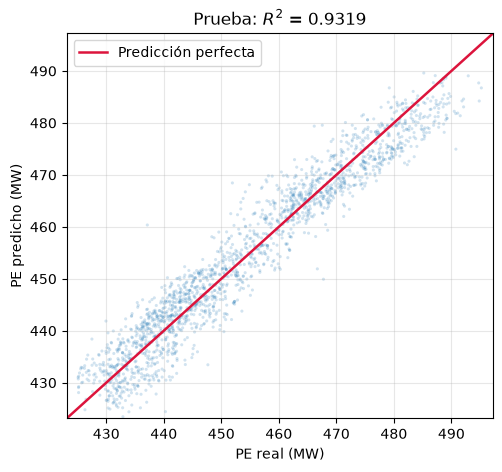

In [12]:
y_predicho = modelo.predict(x_test)

plt.figure(figsize=(5.5, 5))
plt.scatter(y_test, y_predicho, s=5, alpha=.2, edgecolors='none')
limites = [min(y_test) - 2, max(y_test) + 2]
plt.plot(limites, limites, color='crimson', lw=1.8, label='Predicción perfecta')
plt.xlim(limites)
plt.ylim(limites)
plt.xlabel('PE real (MW)')
plt.ylabel('PE predicho (MW)')
plt.title(f'Prueba: $R^2$ = {resultados["Prueba"]["R2"]:.4f}')
plt.legend()
plt.grid(alpha=.3)
guardar('ajuste')

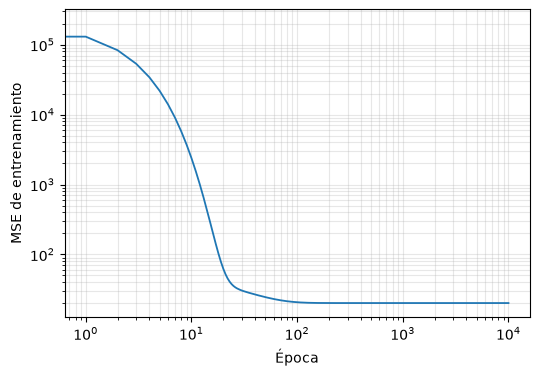

In [13]:
plt.figure(figsize=(6, 4))
plt.plot(modelo.loss_history, lw=1.3)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Época')
plt.ylabel('MSE de entrenamiento')
plt.grid(alpha=.3, which='both')
guardar('perdida')

## 5. Comparación con scikit-learn

In [14]:
from sklearn.linear_model import LinearRegression as SklearnLinearRegression

random.seed(42)
x_sin_escalar, y_sin_escalar, _, _, x_sin_escalar_test, y_sin_escalar_test = split_data(x, y)

referencia = SklearnLinearRegression().fit(np.array(x_sin_escalar).T, y_sin_escalar)
predicho_referencia = referencia.predict(np.array(x_sin_escalar_test).T)
r2_referencia = r2_score(y_sin_escalar_test, list(predicho_referencia))

comparacion = pd.DataFrame(
    [['Manual (GD)'] + [round(b, 4) for b in betas_originales]
     + [round(intercepto_original, 4), round(resultados['Prueba']['R2'], 4)],
     ['scikit-learn (OLS)'] + [round(b, 4) for b in referencia.coef_]
     + [round(referencia.intercept_, 4), round(r2_referencia, 4)]],
    columns=['Modelo'] + [f'beta_{nombre}' for nombre in FEATURES] + ['b', 'R2 prueba'])
comparacion.to_csv(f'{FIGURES}/comparacion.csv', index=False)
comparacion

,Modelo,beta_AT,beta_V,beta_AP,beta_RH,b,R2 prueba
0,Manual (GD),-1.9819,-0.2374,0.0555,-0.1592,461.6212,0.9319
1,scikit-learn (OLS),-1.9819,-0.2374,0.0555,-0.1592,461.6212,0.9319


## 6. Validación cruzada

In [15]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.tree import DecisionTreeRegressor

entradas, objetivo = np.array(x).T, np.array(y)
particiones = KFold(n_splits=5, shuffle=True, random_state=42)

filas = []
for nombre, estimador in [('Regresión lineal', SklearnLinearRegression()),
                          ('Árbol (profundidad 3)', DecisionTreeRegressor(max_depth=3, random_state=42)),
                          ('Random Forest (ajustado)', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))]:
    r2 = cross_val_score(estimador, entradas, objetivo, cv=particiones, scoring='r2')
    rmse = -cross_val_score(estimador, entradas, objetivo, cv=particiones,
                            scoring='neg_root_mean_squared_error')
    filas.append([nombre, round(rmse.mean(), 4), round(rmse.std(), 4),
                  round(r2.mean(), 4), round(r2.std(), 4)])

validacion_cruzada = pd.DataFrame(
    filas, columns=['modelo', 'RMSE medio', 'RMSE desv.', 'R2 medio', 'R2 desv.'])
validacion_cruzada.to_csv(f'{FIGURES}/metricas_cv.csv', index=False)
validacion_cruzada

,modelo,RMSE medio,RMSE desv.,R2 medio,R2 desv.
0,Regresión lineal,4.5603,0.0628,0.9283,0.0020
1,Árbol (profundidad 3),5.1801,0.0565,0.9075,0.0026
2,Random Forest (ajustado),3.3395,0.0993,0.9616,0.0019


## 7. Ajuste de hiperparámetros

In [16]:
tasas = [0.001, 0.01, 0.05, None, 0.5, 0.9]   # None usa la tasa automática
filas = []
curvas = {}

for tasa in tasas:
    etiqueta = 'auto' if tasa is None else f'{tasa}'
    random.seed(42)
    try:
        candidato = LinearRegression([x_train, y_train], learning_rate=tasa, epochs=2000)
        candidato.fit()
        costo_final = candidato.loss_history[-1]
        if math.isnan(costo_final) or math.isinf(costo_final) or costo_final > 1e9:
            raise OverflowError
        medidas = evaluate(y_val, candidato.predict(x_val))
        filas.append([f'auto ({candidato.learning_rate})' if tasa is None else etiqueta,
                      round(costo_final, 3), round(medidas['RMSE'], 3), round(medidas['R2'], 4)])
        curvas[etiqueta] = candidato.loss_history[:2000]
    except (OverflowError, ValueError):
        filas.append([etiqueta, 'diverge', None, None])
        curvas[etiqueta] = None

barrido_tasas = pd.DataFrame(
    filas, columns=['alpha', 'MSE final entren.', 'RMSE val.', 'R2 val.'])
barrido_tasas.to_csv(f'{FIGURES}/lr_sweep.csv', index=False)
barrido_tasas

,alpha,MSE final entren.,RMSE val.,R2 val.
0,0.001,3775.768,61.579,-11.9832
1,0.01,20.722,4.927,0.9169
2,0.05,20.147,4.881,0.9184
3,auto (0.2),20.147,4.881,0.9184
4,0.5,20.147,4.881,0.9184
5,0.9,diverge,NaN,NaN


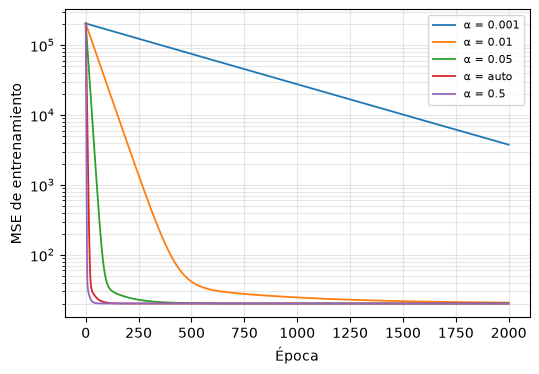

In [17]:
plt.figure(figsize=(6, 4))
for etiqueta, curva in curvas.items():
    if curva is None:
        continue
    plt.plot([valor for valor in curva if valor < 1e12], lw=1.3, label=f'α = {etiqueta}')
plt.yscale('log')
plt.xlabel('Época')
plt.ylabel('MSE de entrenamiento')
plt.legend(fontsize=8)
plt.grid(alpha=.3, which='both')
guardar('lr_sweep')

In [18]:
filas = []
for total_epocas in [100, 500, 1000, 2000, 5000, 10000]:
    random.seed(42)
    candidato = LinearRegression([x_train, y_train], epochs=total_epocas)
    candidato.fit()
    entrenamiento = evaluate(y_train, candidato.predict(x_train))
    validacion = evaluate(y_val, candidato.predict(x_val))
    filas.append([total_epocas, round(entrenamiento['MSE'], 3),
                  round(validacion['MSE'], 3), round(validacion['R2'], 4)])

barrido_epocas = pd.DataFrame(
    filas, columns=['Epocas', 'MSE entren.', 'MSE val.', 'R2 val.'])
barrido_epocas.to_csv(f'{FIGURES}/epochs_sweep.csv', index=False)
barrido_epocas

,Epocas,MSE entren.,MSE val.,R2 val.
0,100,20.698,24.251,0.9170
1,500,20.147,23.825,0.9184
2,1000,20.147,23.825,0.9184
3,2000,20.147,23.825,0.9184
4,5000,20.147,23.825,0.9184
5,10000,20.147,23.825,0.9184
